# cn_full_v3qc_v3 composition (het-mask + merge bug fixed) — k-mer distributions by founder side

**Created 2026-05-18.** Visualizes the k-mer carrier matrix `cn_full_231_v3qc_v3/cn_Chr1.cn.npz` to make the cactus-vs-PG asymmetry concrete.

Plots:
1. **K_f**: total k-mers per founder (row sum) — distribution per side
2. **Private k-mers per founder** (ac=1 columns only) — distribution per side
3. **ac_k**: k-mer multiplicity across founders — overall + per-side breakdown
4. **K_f vs private k-mers per founder** (scatter, colored by side)
5. **Cactus-only-shared / PG-only-shared / mixed** column counts
6. **Shared k-mers per founder** (ac≥2 only)

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.sparse import load_npz

ROOT = Path('/carnegie/nobackup/scratch/tbellagio/hapfire_sv')
CN_PATH   = ROOT / 'poolfreq/data/cn_full_231_v3qc_v3/cn_Chr1.cn.npz'
META_PATH = ROOT / 'poolfreq/data/cn_full_231_v3qc_v3/cn_Chr1.meta.npz'
# Founders come from cn_full meta directly (cn_var rebuild in progress)
SPLIT     = ROOT / 'data/founder_split_cactus_pg.json'

cn = load_npz(CN_PATH).tocsr()
F, K = cn.shape
print(f'cn_full Chr1: shape=({F}, {K:,}) nnz={cn.nnz:,}  density={cn.nnz/(F*K)*100:.3f}%')

# Founder order — pull from cn_var meta (same order as cn_full)
cnfm = np.load(META_PATH, allow_pickle=True)
founders = np.asarray(cnfm['founders']).astype(str)
assert len(founders) == F, f'founder count mismatch: meta={len(founders)}, cn_full={F}'

with open(SPLIT) as f:
    split = json.load(f)
cactus_set = set(map(str, split['cactus']))
pg_set = set(map(str, split['PG']))
is_cactus = np.array([f in cactus_set for f in founders])
is_pg = np.array([f in pg_set for f in founders])
n_cactus = int(is_cactus.sum())
n_pg = int(is_pg.sum())
print(f'cactus founders: {n_cactus}, PG founders: {n_pg}, unlabeled: {F - n_cactus - n_pg}')

cn_full Chr1: shape=(231, 22,673,541) nnz=516,782,103  density=9.867%
cactus founders: 80, PG founders: 151, unlabeled: 0


In [2]:
# Per-founder K_f (row sum)
Kf = np.asarray(cn.sum(axis=1)).flatten()

# Per-kmer ac_k (col sum) — number of founders carrying each k-mer
cnT = cn.T.tocsr()
ac = np.asarray(cn.sum(axis=0)).flatten()

# Per-side cactus/PG kmer participation (founders × kmers → side × kmers)
# n_cactus_carriers_per_kmer: how many cactus founders carry each k-mer
ac_cactus = np.asarray(cn[is_cactus, :].sum(axis=0)).flatten()
ac_pg     = np.asarray(cn[is_pg, :].sum(axis=0)).flatten()
assert np.all(ac == ac_cactus + ac_pg), 'ac decomposition mismatch'

# Private k-mers per founder: k-mers carried by EXACTLY 1 founder. For founder f,
# count of columns where ac=1 AND cn[f, that col] = 1.
ac1_mask = (ac == 1)
n_kmers_total = K
n_priv_kmers = int(ac1_mask.sum())
print(f'Total k-mers (Chr1): {K:,}')
print(f'  ac=0 (no carrier):              {(ac==0).sum():,} ({(ac==0).sum()/K*100:.2f}%)')
print(f'  ac=1 (private k-mers):          {n_priv_kmers:,} ({n_priv_kmers/K*100:.2f}%)')
print(f'  ac=2 (doubletons):              {(ac==2).sum():,}')
print(f'  ac∈[3,10]:                       {((ac>=3)&(ac<=10)).sum():,}')
print(f'  ac>10:                          {(ac>10).sum():,}')

# Per-founder private k-mer count
priv_per_founder = np.asarray(cn[:, ac1_mask].sum(axis=1)).flatten()

print(f'\nPer-founder K_f: median={np.median(Kf):,.0f}, mean={Kf.mean():,.0f}, '
      f'min={Kf.min():,.0f}, max={Kf.max():,.0f}')
print(f'  cactus median K_f: {np.median(Kf[is_cactus]):,.0f}')
print(f'  PG median K_f:     {np.median(Kf[is_pg]):,.0f}')
print(f'  ratio cactus/PG:   {np.median(Kf[is_cactus])/np.median(Kf[is_pg]):.3f}')

print(f'\nPer-founder private k-mers (ac=1): median={np.median(priv_per_founder):,.0f}')
print(f'  cactus median private: {np.median(priv_per_founder[is_cactus]):,.0f}')
print(f'  PG median private:     {np.median(priv_per_founder[is_pg]):,.0f}')
print(f'  ratio cactus/PG:       {np.median(priv_per_founder[is_cactus])/np.median(priv_per_founder[is_pg]):.3f}')

Total k-mers (Chr1): 22,673,541
  ac=0 (no carrier):              5,057,036 (22.30%)
  ac=1 (private k-mers):          6,465,089 (28.51%)
  ac=2 (doubletons):              2,168,878
  ac∈[3,10]:                       4,366,916
  ac>10:                          4,615,622

Per-founder K_f: median=2,237,539, mean=2,237,152, min=1,676,273, max=2,498,623
  cactus median K_f: 2,302,765
  PG median K_f:     2,217,753
  ratio cactus/PG:   1.038

Per-founder private k-mers (ac=1): median=4,335
  cactus median private: 38,415
  PG median private:     2,683
  ratio cactus/PG:       14.318



Per-founder K_f: median=2,237,539, mean=2,237,152, min=1,676,273, max=2,498,623
  cactus median K_f: 2,302,765
  PG median K_f:     2,217,753
  ratio cactus/PG:   1.038

Per-founder private k-mers (ac=1): median=4,335
  cactus median private: 38,415
  PG median private:     2,683
  ratio cactus/PG:       14.318


## Plot 1: K_f distribution — total k-mers per founder, by side

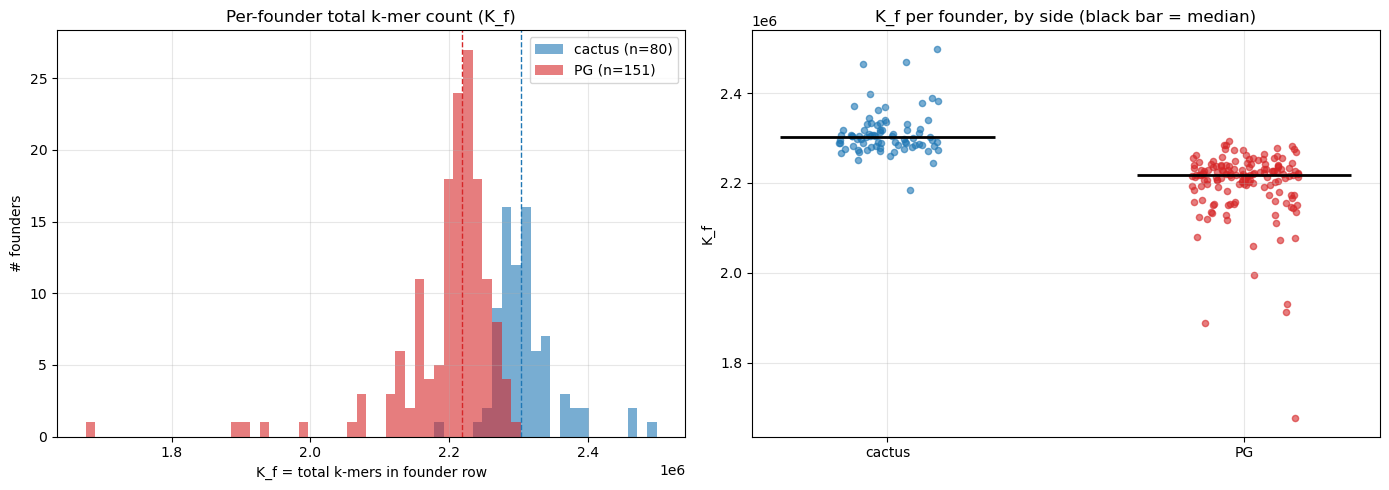

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
bins = np.linspace(Kf.min(), Kf.max(), 60)
ax.hist(Kf[is_cactus], bins=bins, alpha=0.6, color='#1f77b4', label=f'cactus (n={n_cactus})')
ax.hist(Kf[is_pg],     bins=bins, alpha=0.6, color='#d62728', label=f'PG (n={n_pg})')
ax.axvline(np.median(Kf[is_cactus]), color='#1f77b4', ls='--', lw=1)
ax.axvline(np.median(Kf[is_pg]),     color='#d62728', ls='--', lw=1)
ax.set_xlabel('K_f = total k-mers in founder row')
ax.set_ylabel('# founders')
ax.set_title('Per-founder total k-mer count (K_f)')
ax.legend()
ax.grid(alpha=0.3)

# Strip plot (per-founder)
ax = axes[1]
jitter_c = np.random.uniform(-0.15, 0.15, n_cactus)
jitter_p = np.random.uniform(-0.15, 0.15, n_pg)
ax.scatter(jitter_c + 0,   Kf[is_cactus], color='#1f77b4', alpha=0.6, s=20, label=f'cactus')
ax.scatter(jitter_p + 1,   Kf[is_pg],     color='#d62728', alpha=0.6, s=20, label=f'PG')
for x, vals in [(0, Kf[is_cactus]), (1, Kf[is_pg])]:
    ax.hlines(np.median(vals), x-0.3, x+0.3, colors='k', lw=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['cactus', 'PG'])
ax.set_ylabel('K_f')
ax.set_title('K_f per founder, by side (black bar = median)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_v3qc_v3_kf.png', dpi=130, bbox_inches='tight')
plt.show()

## Plot 2: Private k-mer count per founder, by side

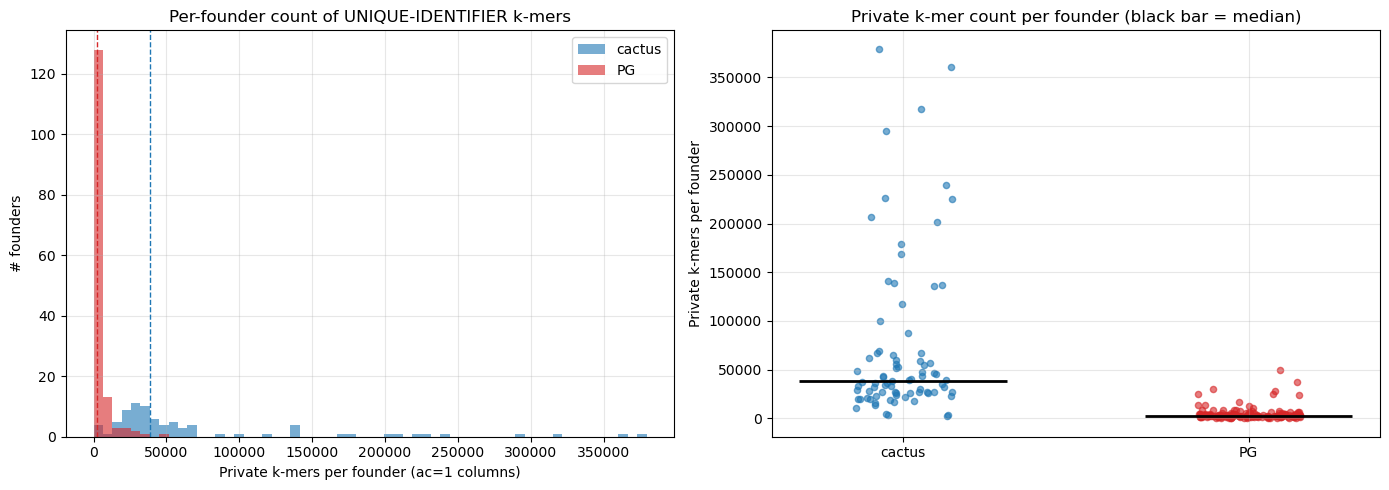

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.linspace(priv_per_founder.min(), priv_per_founder.max(), 60)
ax.hist(priv_per_founder[is_cactus], bins=bins, alpha=0.6, color='#1f77b4', label=f'cactus')
ax.hist(priv_per_founder[is_pg],     bins=bins, alpha=0.6, color='#d62728', label=f'PG')
ax.axvline(np.median(priv_per_founder[is_cactus]), color='#1f77b4', ls='--', lw=1)
ax.axvline(np.median(priv_per_founder[is_pg]),     color='#d62728', ls='--', lw=1)
ax.set_xlabel('Private k-mers per founder (ac=1 columns)')
ax.set_ylabel('# founders')
ax.set_title('Per-founder count of UNIQUE-IDENTIFIER k-mers')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(jitter_c + 0,  priv_per_founder[is_cactus], color='#1f77b4', alpha=0.6, s=20)
ax.scatter(jitter_p + 1,  priv_per_founder[is_pg],     color='#d62728', alpha=0.6, s=20)
for x, vals in [(0, priv_per_founder[is_cactus]), (1, priv_per_founder[is_pg])]:
    ax.hlines(np.median(vals), x-0.3, x+0.3, colors='k', lw=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['cactus', 'PG'])
ax.set_ylabel('Private k-mers per founder')
ax.set_title('Private k-mer count per founder (black bar = median)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_v3qc_v3_private.png', dpi=130, bbox_inches='tight')
plt.show()

## Plot 3: ac_k distribution — k-mer multiplicity across all founders

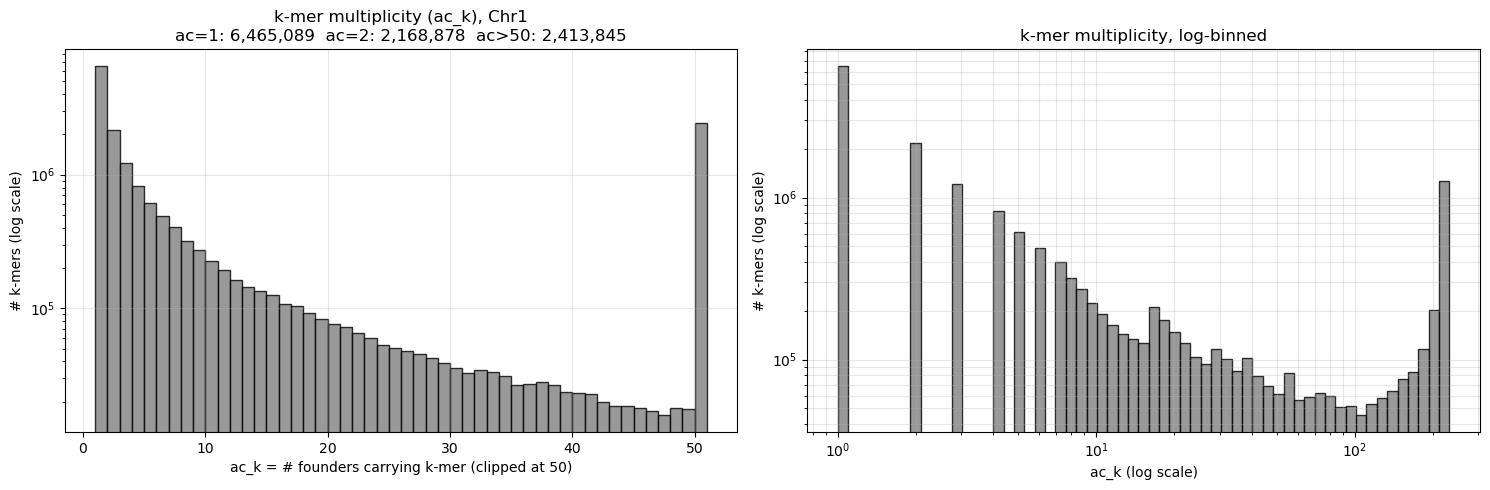

In [5]:
# Truncated histogram: keep ac in [1, 50] for readability; tail bucket for ac>50
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Linear bins
ax = axes[0]
ac_clip = np.minimum(ac, 50)
ax.hist(ac_clip[ac > 0], bins=np.arange(1, 52), color='gray', edgecolor='k', alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel('ac_k = # founders carrying k-mer (clipped at 50)')
ax.set_ylabel('# k-mers (log scale)')
ax.set_title(f'k-mer multiplicity (ac_k), Chr1\nac=1: {(ac==1).sum():,}  ac=2: {(ac==2).sum():,}  ac>50: {(ac>50).sum():,}')
ax.grid(alpha=0.3)

# Log-bin: shows the full tail structure
ax = axes[1]
log_bins = np.logspace(0, np.log10(F + 1), 60)
ax.hist(ac[ac > 0], bins=log_bins, color='gray', edgecolor='k', alpha=0.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('ac_k (log scale)')
ax.set_ylabel('# k-mers (log scale)')
ax.set_title('k-mer multiplicity, log-binned')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_v3qc_v3_ac.png', dpi=130, bbox_inches='tight')
plt.show()

## Plot 4: Cactus-only-shared / PG-only-shared / mixed k-mer breakdown

For each k-mer with ac≥2, classify by carrier composition:
- **all-cactus**: carriers ⊂ cactus founders
- **all-PG**: carriers ⊂ PG founders
- **mixed**: at least one carrier from each side

Shared k-mers (ac>=2) on Chr1: 11,151,416
  all-cactus (no PG carriers):   874,178 (7.8%)
  all-PG (no cactus carriers):   497,609     (4.5%)
  mixed (both sides):            9,779,629     (87.7%)


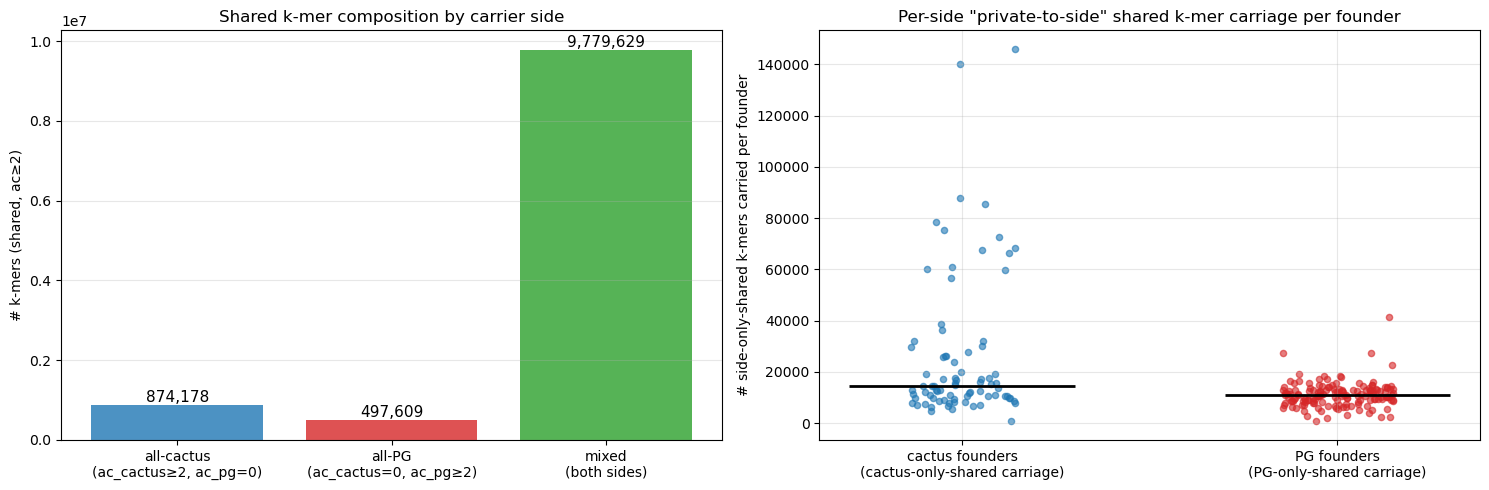


Per-founder side-only-shared k-mer carriage:
  cactus median (cactus-only-shared per cactus founder): 14,550
  PG     median (PG-only-shared per PG founder):         10,847
  ratio: 1.34


In [6]:
ac_shared_mask = ac >= 2
n_shared = int(ac_shared_mask.sum())

all_cactus = ac_shared_mask & (ac_pg == 0) & (ac_cactus >= 2)
all_pg     = ac_shared_mask & (ac_cactus == 0) & (ac_pg >= 2)
mixed      = ac_shared_mask & (ac_cactus >= 1) & (ac_pg >= 1)

# Sanity: should partition the shared set
assert all_cactus.sum() + all_pg.sum() + mixed.sum() == n_shared, 'partition mismatch'

print(f'Shared k-mers (ac>=2) on Chr1: {n_shared:,}')
print(f'  all-cactus (no PG carriers):   {all_cactus.sum():,} ({all_cactus.sum()/n_shared*100:.1f}%)')
print(f'  all-PG (no cactus carriers):   {all_pg.sum():,}     ({all_pg.sum()/n_shared*100:.1f}%)')
print(f'  mixed (both sides):            {mixed.sum():,}     ({mixed.sum()/n_shared*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of counts
ax = axes[0]
categories = ['all-cactus\n(ac_cactus≥2, ac_pg=0)',
              'all-PG\n(ac_cactus=0, ac_pg≥2)',
              'mixed\n(both sides)']
counts = [int(all_cactus.sum()), int(all_pg.sum()), int(mixed.sum())]
colors = ['#1f77b4', '#d62728', '#2ca02c']
bars = ax.bar(categories, counts, color=colors, alpha=0.8)
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{c:,}',
            ha='center', va='bottom', fontsize=11)
ax.set_ylabel('# k-mers (shared, ac≥2)')
ax.set_title('Shared k-mer composition by carrier side')
ax.grid(alpha=0.3, axis='y')

# Per-founder breakdown: how many cactus-only-shared k-mers does each cactus founder carry?
# (Compare to all-PG-shared per PG founder)
ax = axes[1]
cactus_only_per_founder = np.asarray(cn[:, all_cactus].sum(axis=1)).flatten()
pg_only_per_founder     = np.asarray(cn[:, all_pg].sum(axis=1)).flatten()
mixed_per_founder       = np.asarray(cn[:, mixed].sum(axis=1)).flatten()

ax.scatter(jitter_c + 0, cactus_only_per_founder[is_cactus], color='#1f77b4', alpha=0.6, s=20)
ax.scatter(jitter_p + 1, pg_only_per_founder[is_pg],         color='#d62728', alpha=0.6, s=20)
for x, vals in [(0, cactus_only_per_founder[is_cactus]),
                (1, pg_only_per_founder[is_pg])]:
    ax.hlines(np.median(vals), x-0.3, x+0.3, colors='k', lw=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['cactus founders\n(cactus-only-shared carriage)',
                                            'PG founders\n(PG-only-shared carriage)'])
ax.set_ylabel('# side-only-shared k-mers carried per founder')
ax.set_title('Per-side "private-to-side" shared k-mer carriage per founder')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_v3qc_v3_side_shared.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'\nPer-founder side-only-shared k-mer carriage:')
print(f'  cactus median (cactus-only-shared per cactus founder): {np.median(cactus_only_per_founder[is_cactus]):,.0f}')
print(f'  PG     median (PG-only-shared per PG founder):         {np.median(pg_only_per_founder[is_pg]):,.0f}')
print(f'  ratio: {np.median(cactus_only_per_founder[is_cactus]) / np.median(pg_only_per_founder[is_pg]):.2f}')

## Plot 5: K_f vs private k-mer count (scatter, colored by side)

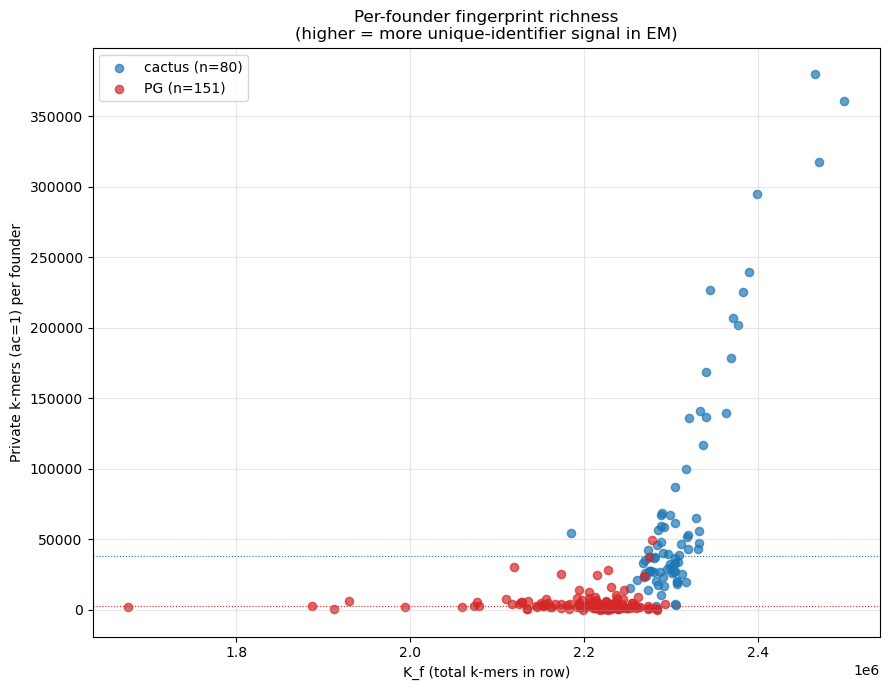

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(Kf[is_cactus], priv_per_founder[is_cactus], color='#1f77b4', alpha=0.7, s=35, label=f'cactus (n={n_cactus})')
ax.scatter(Kf[is_pg],     priv_per_founder[is_pg],     color='#d62728', alpha=0.7, s=35, label=f'PG (n={n_pg})')
ax.axhline(np.median(priv_per_founder[is_cactus]), color='#1f77b4', ls=':', lw=0.8)
ax.axhline(np.median(priv_per_founder[is_pg]),     color='#d62728', ls=':', lw=0.8)
ax.set_xlabel('K_f (total k-mers in row)')
ax.set_ylabel('Private k-mers (ac=1) per founder')
ax.set_title('Per-founder fingerprint richness\n(higher = more unique-identifier signal in EM)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_v3qc_v3_kf_vs_priv.png', dpi=130, bbox_inches='tight')
plt.show()

## Summary table

In [8]:
import pandas as pd
summary = pd.DataFrame({
    'metric': [
        'n founders',
        'K_f median (total k-mers per founder)',
        'K_f mean',
        'private k-mers per founder (median)',
        'cactus-only-shared k-mers per founder (median)',
        'PG-only-shared k-mers per founder (median)',
        'mixed-shared k-mers per founder (median)',
    ],
    'cactus': [
        n_cactus,
        f'{np.median(Kf[is_cactus]):,.0f}',
        f'{Kf[is_cactus].mean():,.0f}',
        f'{np.median(priv_per_founder[is_cactus]):,.0f}',
        f'{np.median(cactus_only_per_founder[is_cactus]):,.0f}',
        f'{np.median(pg_only_per_founder[is_cactus]):,.0f} (carriage = 0 by construction)',
        f'{np.median(mixed_per_founder[is_cactus]):,.0f}',
    ],
    'PG': [
        n_pg,
        f'{np.median(Kf[is_pg]):,.0f}',
        f'{Kf[is_pg].mean():,.0f}',
        f'{np.median(priv_per_founder[is_pg]):,.0f}',
        f'{np.median(cactus_only_per_founder[is_pg]):,.0f} (carriage = 0 by construction)',
        f'{np.median(pg_only_per_founder[is_pg]):,.0f}',
        f'{np.median(mixed_per_founder[is_pg]):,.0f}',
    ],
})
print(summary.to_string(index=False))

                                        metric                           cactus                               PG
                                    n founders                               80                              151
         K_f median (total k-mers per founder)                        2,302,765                        2,217,753
                                      K_f mean                        2,309,800                        2,198,663
           private k-mers per founder (median)                           38,415                            2,683
cactus-only-shared k-mers per founder (median)                           14,550 0 (carriage = 0 by construction)
    PG-only-shared k-mers per founder (median) 0 (carriage = 0 by construction)                           10,847
      mixed-shared k-mers per founder (median)                        2,236,490                        2,201,186


# Effect of "mixed-only" subsetting on cn_full composition

How does restricting cn_full to k-mers carried by BOTH cactus AND PG sides change the per-founder distribution? Three tiers compared:

- **mixed-loose**: `ac_cactus ≥ 1 AND ac_pg ≥ 1` — every k-mer has at least 1 cactus AND 1 PG carrier. Drops cactus-only and PG-only shared k-mers + all private k-mers.
- **mixed-strict**: `ac_cactus ≥ 5 AND ac_pg ≥ 5` — k-mers carried by ≥5 founders per side.
- **mixed-conserv**: `ac_cactus ≥ 10 AND ac_pg ≥ 10` — k-mers carried by ≥10 founders per side.

The "mixed-only" filter is conceptually parallel to what hapFIRE does (uses SNP data which is reliably called on both panels). It rebalances at the data level — no post-hoc correction needed.

In [9]:
# Define the three mixed-only masks on the existing ac/ac_cactus/ac_pg arrays
mask_full       = np.ones(K, dtype=bool)
mask_loose      = (ac_cactus >= 1) & (ac_pg >= 1)
mask_strict     = (ac_cactus >= 5) & (ac_pg >= 5)
mask_conserv    = (ac_cactus >= 10) & (ac_pg >= 10)

TIER_LABELS = ['full', 'mixed-loose', 'mixed-strict', 'mixed-conserv']
TIER_MASKS  = [mask_full, mask_loose, mask_strict, mask_conserv]
TIER_COLORS = ['#444444', '#2ca02c', '#1f77b4', '#9467bd']

# Compute per-founder K_f and per-founder private k-mers for each tier
tier_stats = {}
for label, m in zip(TIER_LABELS, TIER_MASKS):
    sub = cn[:, m]
    Kf_t = np.asarray(sub.sum(axis=1)).flatten()
    ac_t = np.asarray(sub.sum(axis=0)).flatten()
    # private-within-tier: ac==1 columns
    priv_mask = (ac_t == 1)
    priv_t = np.asarray(sub[:, priv_mask].sum(axis=1)).flatten() if priv_mask.sum() else np.zeros(F)
    tier_stats[label] = {
        'n_kmers': int(m.sum()),
        'Kf': Kf_t,
        'priv_per_founder': priv_t,
        'mask': m,
    }
    print(f'  {label:>16s}: n_kmers={m.sum():>12,}  '
          f'K_f cactus med={int(np.median(Kf_t[is_cactus])):>9,}  '
          f'PG med={int(np.median(Kf_t[is_pg])):>9,}  '
          f'ratio={np.median(Kf_t[is_cactus])/max(np.median(Kf_t[is_pg]),1):.3f}')

              full: n_kmers=  22,673,541  K_f cactus med=2,302,765  PG med=2,217,753  ratio=1.038
       mixed-loose: n_kmers=   9,779,629  K_f cactus med=2,236,490  PG med=2,201,186  ratio=1.016
      mixed-strict: n_kmers=   4,128,807  K_f cactus med=2,093,418  PG med=2,066,819  ratio=1.013
     mixed-conserv: n_kmers=   3,033,803  K_f cactus med=1,993,206  PG med=1,976,426  ratio=1.008


      mixed-strict: n_kmers=   4,128,807  K_f cactus med=2,093,418  PG med=2,066,819  ratio=1.013


     mixed-conserv: n_kmers=   3,033,803  K_f cactus med=1,993,206  PG med=1,976,426  ratio=1.008


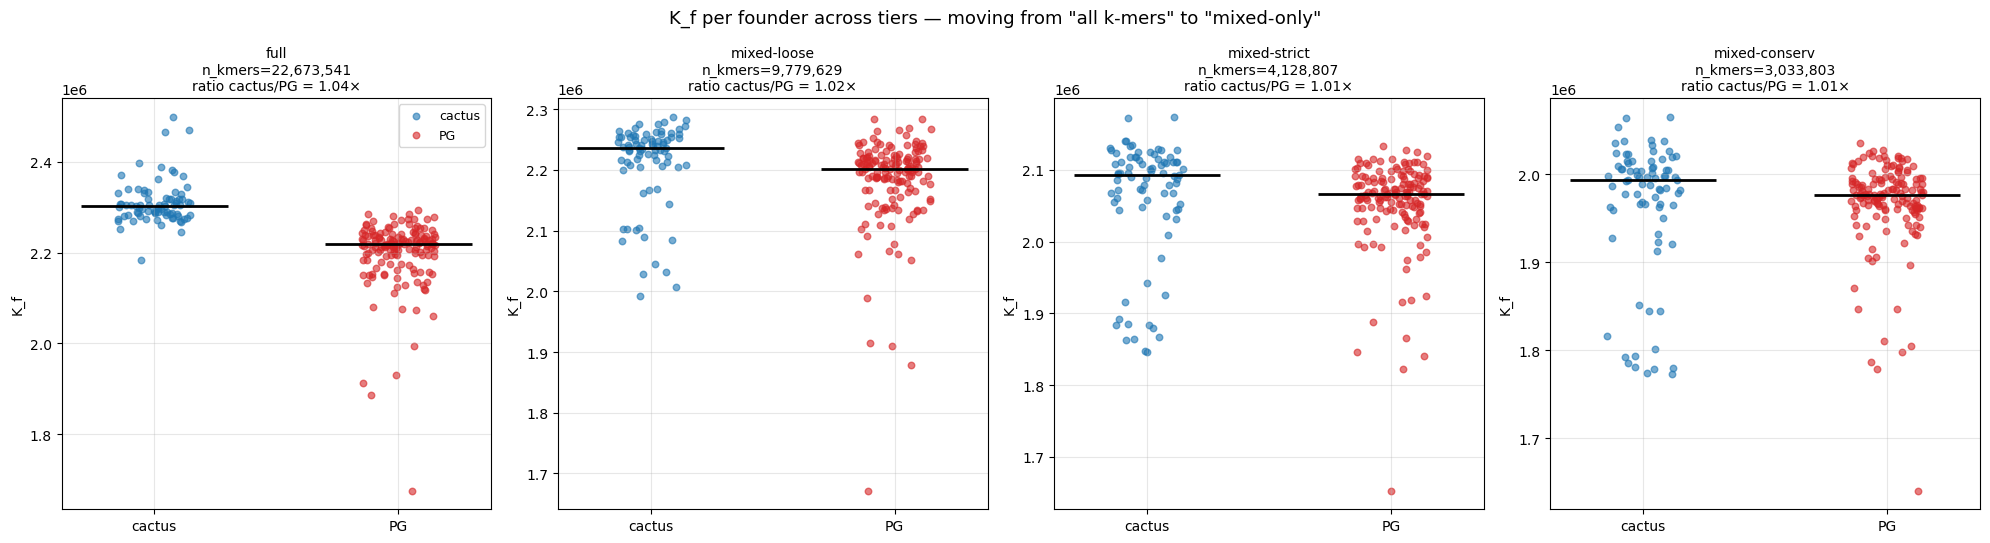

In [10]:
# Plot: per-tier K_f distributions per side (strip plots side-by-side)
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5), sharey=False)
for i, label in enumerate(TIER_LABELS):
    ax = axes[i]
    Kf_t = tier_stats[label]['Kf']
    jc = np.random.uniform(-0.15, 0.15, n_cactus)
    jp = np.random.uniform(-0.15, 0.15, n_pg)
    ax.scatter(jc + 0, Kf_t[is_cactus], color='#1f77b4', alpha=0.6, s=22, label='cactus')
    ax.scatter(jp + 1, Kf_t[is_pg],     color='#d62728', alpha=0.6, s=22, label='PG')
    for x, vals in [(0, Kf_t[is_cactus]), (1, Kf_t[is_pg])]:
        ax.hlines(np.median(vals), x-0.3, x+0.3, colors='k', lw=2)
    med_c = np.median(Kf_t[is_cactus]); med_p = np.median(Kf_t[is_pg])
    ratio = med_c / max(med_p, 1)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['cactus', 'PG'])
    ax.set_ylabel('K_f')
    ax.set_title(f'{label}\nn_kmers={tier_stats[label]["n_kmers"]:,}\nratio cactus/PG = {ratio:.2f}×',
                 fontsize=10)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle('K_f per founder across tiers — moving from "all k-mers" to "mixed-only"',
             fontsize=13)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_v3qc_v3_mixedtiers_kf.png', dpi=130, bbox_inches='tight')
plt.show()

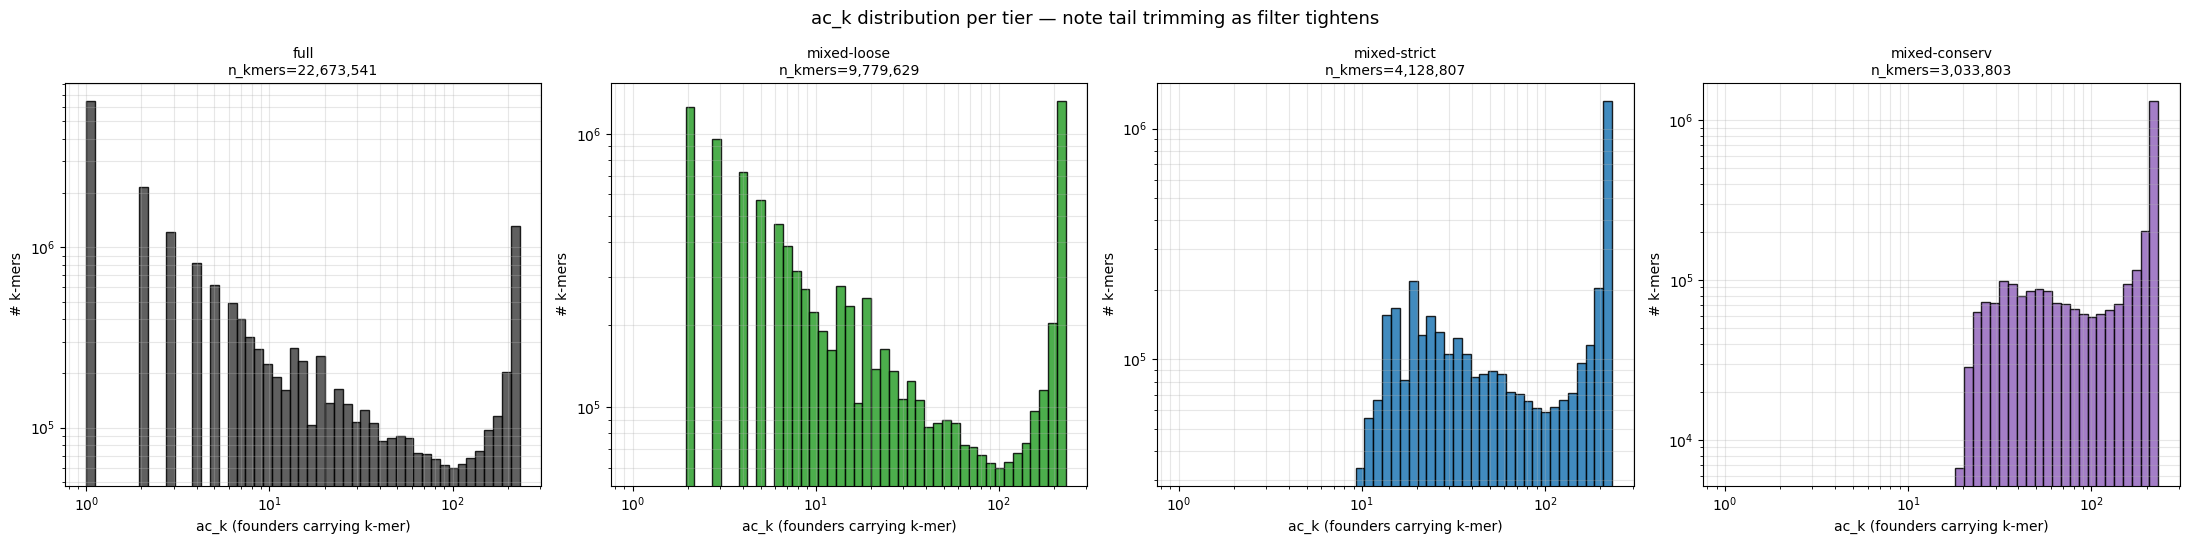

In [11]:
# Plot: per-tier ac_k distributions on the SUBSET
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharey=False)
for i, label in enumerate(TIER_LABELS):
    ax = axes[i]
    m = tier_stats[label]['mask']
    ac_sub = ac[m]
    log_bins = np.logspace(0, np.log10(F + 1), 50)
    ax.hist(ac_sub, bins=log_bins, color=TIER_COLORS[i], edgecolor='k', alpha=0.85)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('ac_k (founders carrying k-mer)')
    ax.set_ylabel('# k-mers')
    ax.set_title(f'{label}\nn_kmers={m.sum():,}', fontsize=10)
    ax.grid(alpha=0.3, which='both')

plt.suptitle('ac_k distribution per tier — note tail trimming as filter tightens', fontsize=13)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_v3qc_v3_mixedtiers_ac.png', dpi=130, bbox_inches='tight')
plt.show()

In [12]:
# Summary table: per-tier metrics
import pandas as pd
rows = []
for label in TIER_LABELS:
    Kf_t = tier_stats[label]['Kf']
    priv_t = tier_stats[label]['priv_per_founder']
    rows.append({
        'tier': label,
        'n_kmers': tier_stats[label]['n_kmers'],
        'frac_of_full': f'{tier_stats[label]["n_kmers"]/K*100:.2f}%',
        'Kf_cactus_med': f'{int(np.median(Kf_t[is_cactus])):,}',
        'Kf_PG_med': f'{int(np.median(Kf_t[is_pg])):,}',
        'Kf_ratio_C/PG': f'{np.median(Kf_t[is_cactus])/max(np.median(Kf_t[is_pg]),1):.3f}',
        'priv_cactus_med': f'{int(np.median(priv_t[is_cactus])):,}',
        'priv_PG_med': f'{int(np.median(priv_t[is_pg])):,}',
    })
tier_df = pd.DataFrame(rows)
print(tier_df.to_string(index=False))

         tier  n_kmers frac_of_full Kf_cactus_med Kf_PG_med Kf_ratio_C/PG priv_cactus_med priv_PG_med
         full 22673541      100.00%     2,302,765 2,217,753         1.038          38,415       2,683
  mixed-loose  9779629       43.13%     2,236,490 2,201,186         1.016               0           0
 mixed-strict  4128807       18.21%     2,093,418 2,066,819         1.013               0           0
mixed-conserv  3033803       13.38%     1,993,206 1,976,426         1.008               0           0


In [13]:
tier_df

,tier,n_kmers,frac_of_full,Kf_cactus_med,Kf_PG_med,Kf_ratio_C/PG,priv_cactus_med,priv_PG_med
0,full,22673541,100.00%,"2,302,765","2,217,753",1.038,"38,415","2,683"
1,mixed-loose,9779629,43.13%,"2,236,490","2,201,186",1.016,0,0
2,mixed-strict,4128807,18.21%,"2,093,418","2,066,819",1.013,0,0
3,mixed-conserv,3033803,13.38%,"1,993,206","1,976,426",1.008,0,0


## Plot 5 across tiers — K_f vs private k-mers per founder, full vs mixed-loose / strict / conserv

Same axes as Plot 5 (K_f on x, within-tier private k-mers on y, blue=cactus / red=PG), reproduced once per tier so the effect of the mixed-only filter on the per-founder fingerprint distribution is visible at a glance.

Note: "private (ac=1)" is recomputed *within each tier subset* — for the mixed-loose / strict / conserv tiers every retained k-mer must have a carrier on each side, so the within-tier ac=1 column count is structurally zero. The y-axis flattening is the visual signature of that constraint, not an artefact.

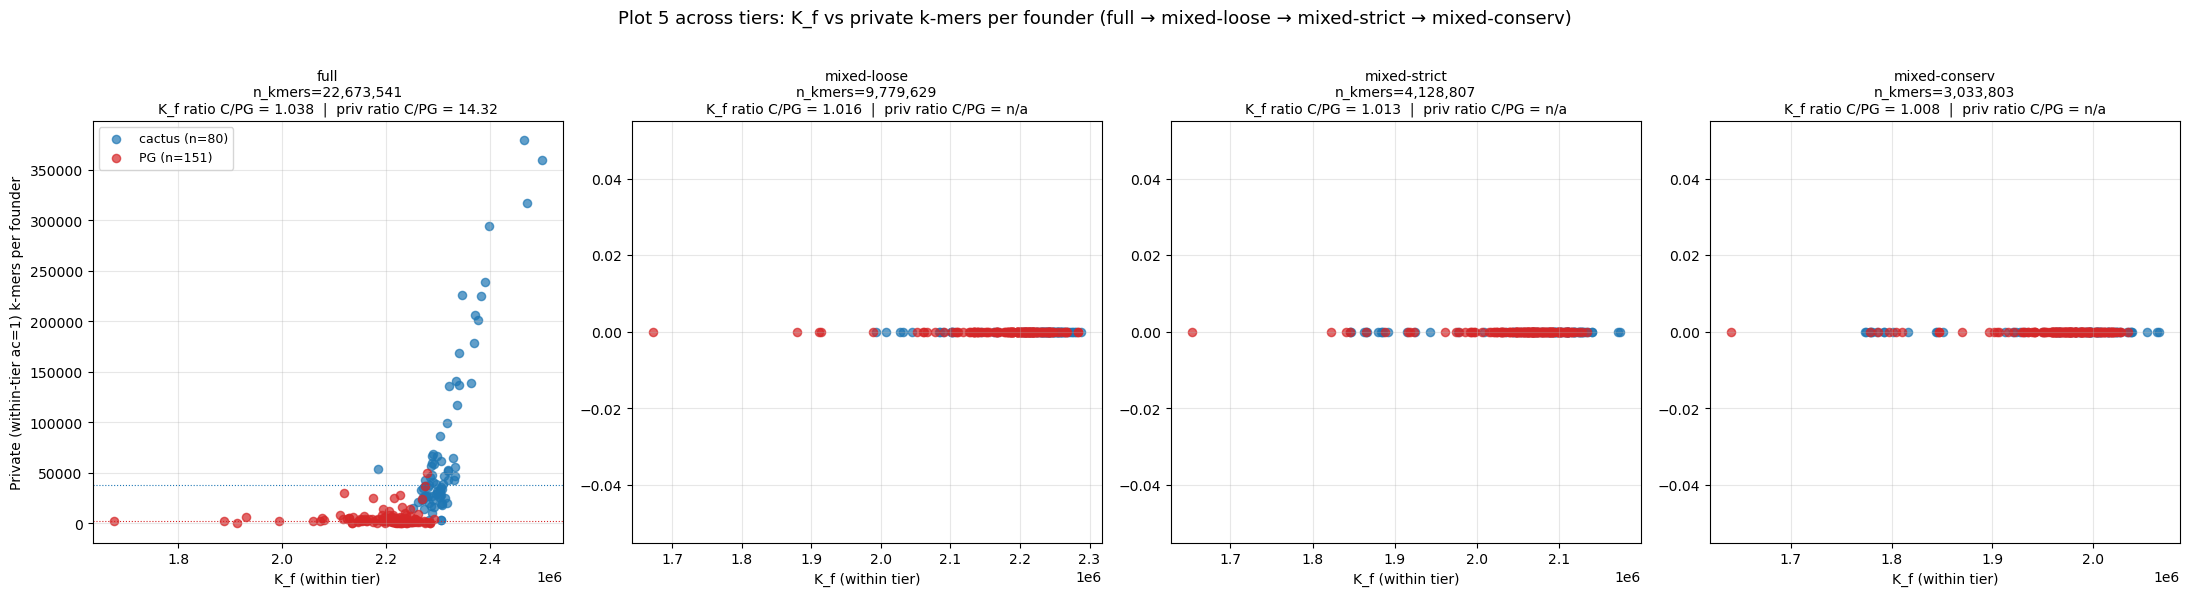

In [14]:
# Plot 5 across tiers: K_f vs (within-tier) private k-mers per founder, colored by side
fig, axes = plt.subplots(1, 4, figsize=(22, 5.8))

for i, label in enumerate(TIER_LABELS):
    ax = axes[i]
    Kf_t = tier_stats[label]['Kf']
    priv_t = tier_stats[label]['priv_per_founder']

    ax.scatter(Kf_t[is_cactus], priv_t[is_cactus], color='#1f77b4',
               alpha=0.7, s=35, label=f'cactus (n={n_cactus})')
    ax.scatter(Kf_t[is_pg], priv_t[is_pg], color='#d62728',
               alpha=0.7, s=35, label=f'PG (n={n_pg})')

    med_c_priv = np.median(priv_t[is_cactus])
    med_p_priv = np.median(priv_t[is_pg])
    if med_c_priv > 0:
        ax.axhline(med_c_priv, color='#1f77b4', ls=':', lw=0.8)
    if med_p_priv > 0:
        ax.axhline(med_p_priv, color='#d62728', ls=':', lw=0.8)

    ratio_kf   = np.median(Kf_t[is_cactus])   / max(np.median(Kf_t[is_pg]),   1)
    ratio_priv = (med_c_priv / med_p_priv) if med_p_priv > 0 else float('nan')

    ax.set_xlabel('K_f (within tier)')
    if i == 0:
        ax.set_ylabel('Private (within-tier ac=1) k-mers per founder')
    ax.set_title(
        f'{label}\nn_kmers={tier_stats[label]["n_kmers"]:,}\n'
        f'K_f ratio C/PG = {ratio_kf:.3f}  |  '
        f"priv ratio C/PG = {('%.2f' % ratio_priv) if np.isfinite(ratio_priv) else 'n/a'}",
        fontsize=10,
    )
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Plot 5 across tiers: K_f vs private k-mers per founder '
             '(full → mixed-loose → mixed-strict → mixed-conserv)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_v3qc_v3_kf_vs_priv_tiers.png',
            dpi=130, bbox_inches='tight')
plt.show()


## Plot 6: Label extreme founders by name (adjustText for non-overlap)

Identify the individual ecotypes sitting far from their side's centroid. Labels only the top extreme founders per side (by squared z-score in K_f + side-only-shared dimensions); the bulk concentration around the median is left unlabeled.

AttributeError: 'Annotation' object has no property 'expand'

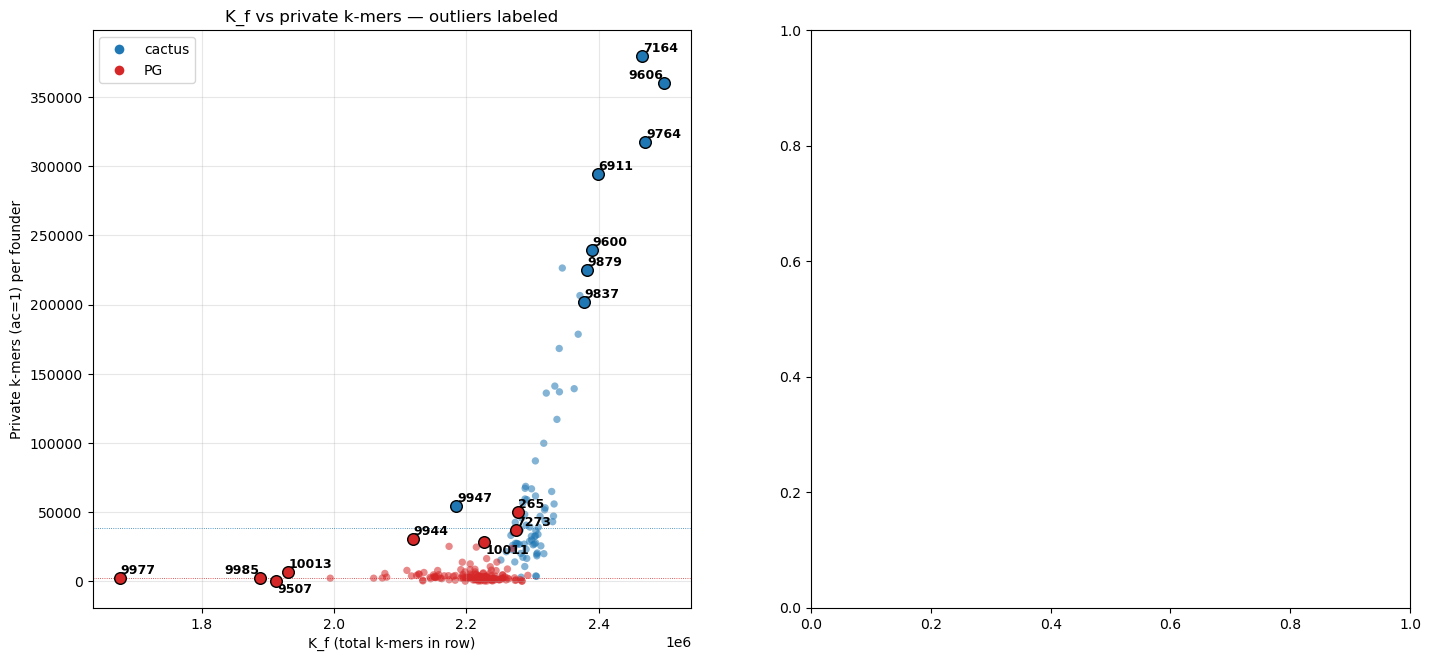

In [15]:
from adjustText import adjust_text

# Two scatters: K_f vs private k-mers per founder, K_f vs side-only-shared per founder.
# Label only the top N extreme founders per side (largest squared z-score in (x, y)).

def label_extremes(ax, x, y, names, side_mask, color, n_label=8):
    """Plot all founders for one side, then label only the top-N outliers
    (by joint z-score in (x, y)). Returns the matplotlib Text objects for
    adjustText to relax."""
    xs, ys, nm = x[side_mask], y[side_mask], names[side_mask]
    ax.scatter(xs, ys, color=color, alpha=0.55, s=28, edgecolor='none')
    if len(xs) < n_label:
        return []
    # z-score per dimension within the side
    zx = (xs - np.median(xs)) / (np.std(xs) + 1e-9)
    zy = (ys - np.median(ys)) / (np.std(ys) + 1e-9)
    score = zx**2 + zy**2
    top = np.argsort(score)[-n_label:]
    texts = []
    for i in top:
        ax.scatter(xs[i], ys[i], color=color, edgecolor='black', s=70, lw=1, zorder=10)
        texts.append(ax.text(xs[i], ys[i], str(nm[i]), fontsize=9, fontweight='bold',
                             color='black'))
    return texts

founders_arr = np.asarray(founders)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))

# --- Left: K_f vs private k-mers per founder ---
ax = axes[0]
t1 = label_extremes(ax, Kf, priv_per_founder, founders_arr, is_cactus, '#1f77b4', n_label=8)
t2 = label_extremes(ax, Kf, priv_per_founder, founders_arr, is_pg,     '#d62728', n_label=8)
ax.axhline(np.median(priv_per_founder[is_cactus]), color='#1f77b4', ls=':', lw=0.6)
ax.axhline(np.median(priv_per_founder[is_pg]),     color='#d62728', ls=':', lw=0.6)
ax.set_xlabel('K_f (total k-mers in row)')
ax.set_ylabel('Private k-mers (ac=1) per founder')
ax.set_title('K_f vs private k-mers — outliers labeled')
ax.legend([plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=8, label='cactus'),
           plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#d62728', markersize=8, label='PG')],
          ['cactus', 'PG'], loc='upper left')
ax.grid(alpha=0.3)
adjust_text(t1 + t2, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
            expand=(1.2, 1.5))

# --- Right: K_f vs side-only-shared k-mers per founder ---
ax = axes[1]
# For cactus founders use cactus_only_per_founder; for PG use pg_only_per_founder.
# Both metrics are in cactus_only_per_founder / pg_only_per_founder vars (set to 0 on
# the wrong side by construction). Show only the within-side metric for each founder.
y_side_only = np.where(is_cactus, cactus_only_per_founder, pg_only_per_founder)
t3 = label_extremes(ax, Kf, y_side_only, founders_arr, is_cactus, '#1f77b4', n_label=8)
t4 = label_extremes(ax, Kf, y_side_only, founders_arr, is_pg,     '#d62728', n_label=8)
ax.axhline(np.median(cactus_only_per_founder[is_cactus]), color='#1f77b4', ls=':', lw=0.6)
ax.axhline(np.median(pg_only_per_founder[is_pg]),         color='#d62728', ls=':', lw=0.6)
ax.set_xlabel('K_f (total k-mers in row)')
ax.set_ylabel('Side-only-shared k-mers carried per founder')
ax.set_title('K_f vs side-only-shared carriage — outliers labeled\n'
             '(cactus uses cactus-only-shared, PG uses PG-only-shared)')
ax.legend([plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=8),
           plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#d62728', markersize=8)],
          ['cactus', 'PG'], loc='upper left')
ax.grid(alpha=0.3)
adjust_text(t3 + t4, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
            expand=(1.2, 1.5))

plt.suptitle('Extreme ecotypes in cn_full_v3qc_v3 (Chr1) — top 8 outliers per side labeled',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_v3qc_v3_extreme_ecotypes.png', dpi=140, bbox_inches='tight')
plt.show()

# Numerical: list the labeled extremes for reference
print('\n=== Top extreme cactus founders (combined z-score on K_f + private) ===')
zc = ((Kf - np.median(Kf[is_cactus]))[is_cactus] / np.std(Kf[is_cactus]))**2 + \
     ((priv_per_founder - np.median(priv_per_founder[is_cactus]))[is_cactus] / np.std(priv_per_founder[is_cactus]))**2
idx_c = np.where(is_cactus)[0]
order_c = np.argsort(zc)[-8:][::-1]
for j in order_c:
    i = idx_c[j]
    print(f'  {founders_arr[i]:>8s}: K_f={int(Kf[i]):>9,}, priv={int(priv_per_founder[i]):>7,}, '
          f'cactus-only-shared={int(cactus_only_per_founder[i]):>7,}')

print('\n=== Top extreme PG founders ===')
zp = ((Kf - np.median(Kf[is_pg]))[is_pg] / np.std(Kf[is_pg]))**2 + \
     ((priv_per_founder - np.median(priv_per_founder[is_pg]))[is_pg] / np.std(priv_per_founder[is_pg]))**2
idx_p = np.where(is_pg)[0]
order_p = np.argsort(zp)[-8:][::-1]
for j in order_p:
    i = idx_p[j]
    print(f'  {founders_arr[i]:>8s}: K_f={int(Kf[i]):>9,}, priv={int(priv_per_founder[i]):>7,}, '
          f'pg-only-shared={int(pg_only_per_founder[i]):>7,}')

## Plot 7: cross-check extremes with upstream QC data

For each founder, plot K_f vs private k-mers, colored by the upstream QC metric that's appropriate for its side:

- **Cactus founders** (long-read assembly-based): colored by **LOO PG-vs-cactus disagreement %** (from `_tmp_per_founder_gt_disagreement.tsv`). Fernando-flagged founders (`flag_list.tsv`) are marked with an outlined ring. Tests whether high-k-mer-richness cactus founders are the same ones with poor LOO concordance.
- **PG founders** (short-read PanGenie-based): colored by **short-read coverage** (computed from `ena_manifest.tsv`: base_count / 135Mbp). Low-coverage founders should cluster at low K_f.

Cross-check answers: do our k-mer-composition extremes match the known QC tags from independent upstream evidence?

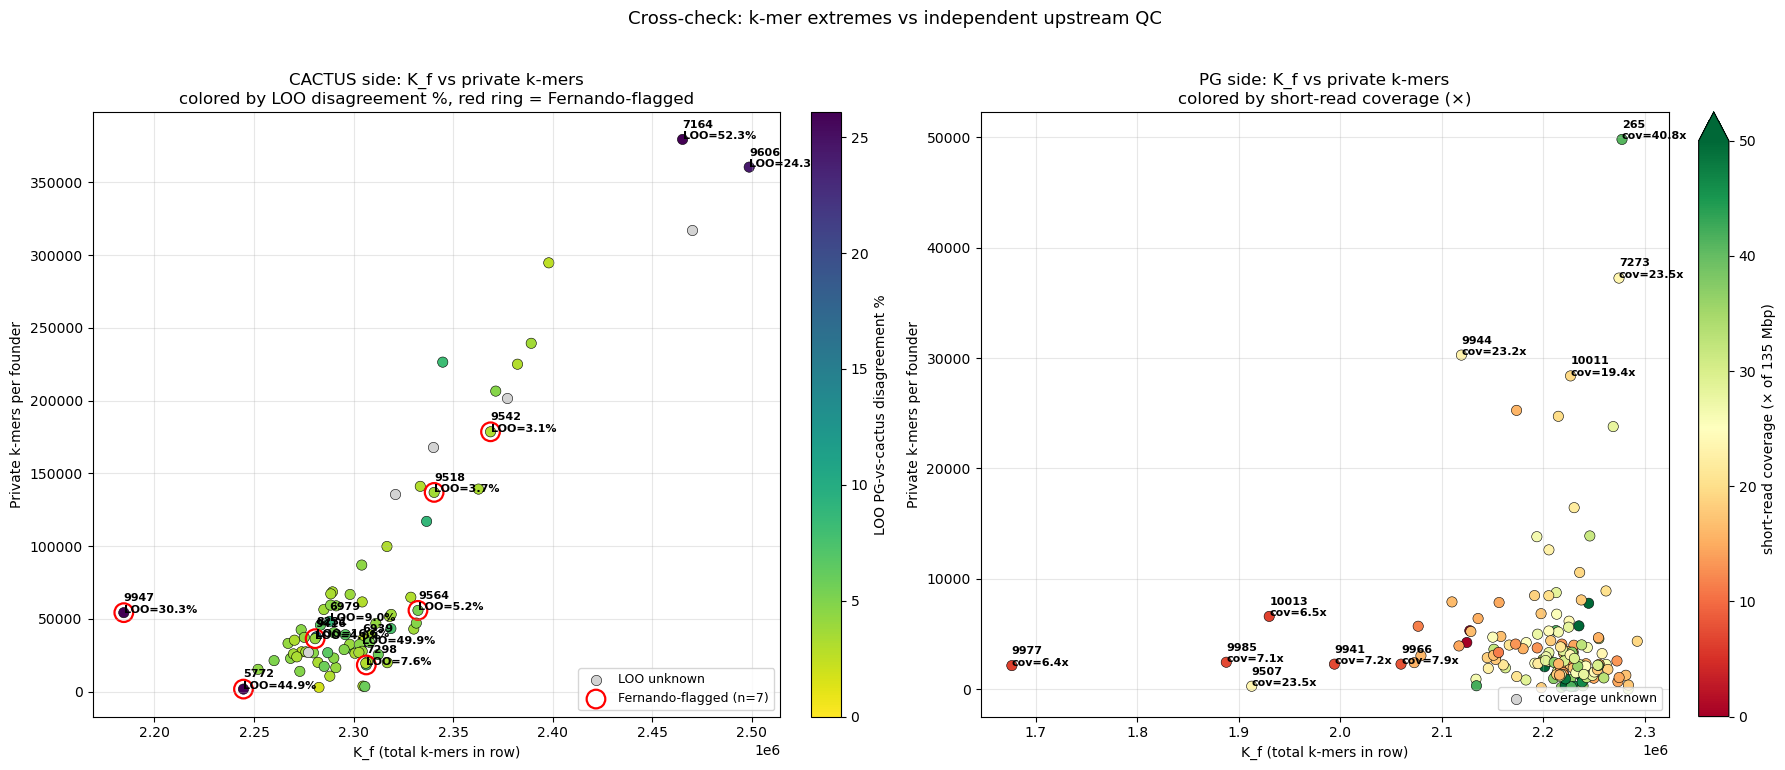

In [17]:
import os, glob
import pandas as pd
from adjustText import adjust_text

# --- LOO disagreement (cactus-side QC) ---
LOO_DIR = ROOT / 'pangenie_genotyping/data/loo_concordance'
_loo_rows = []
for f in sorted(glob.glob(str(LOO_DIR / '*_summary.tsv'))):
    acc = os.path.basename(f).split('_')[0]
    _df = pd.read_csv(f, sep='\t')
    _tv = _df['n_nonref_either'].sum()
    _td = _df['n_nonref_disc'].sum()
    _loo_rows.append({'founder': acc,
                      'pct_disagree': 100.0 * _td / _tv if _tv > 0 else float('nan')})
loo_map = dict(zip([r['founder'] for r in _loo_rows],
                   [r['pct_disagree'] for r in _loo_rows]))

# --- Fernando flags (only the 3 Fernando-origin statuses) ---
FERNANDO_STATUSES = {
    'exclude-cactus-keep-pg',
    'flag-low-cov-but-concordance-OK',
    'flag-het-but-concordance-OK',
}
flag_df = pd.read_csv(ROOT / 'data/flag_list.tsv', sep='\t', dtype={'Accession_ID': str})
flag_map = dict(zip(flag_df['Accession_ID'].astype(str), flag_df['Status']))

# --- Short-read coverage (PG-side) ---
GENOME_SIZE = 135_000_000
ena = pd.read_csv(ROOT / 'pangenie_genotyping/data/ena_manifest.tsv', sep='\t', dtype={'ecotype_id': str})
cov_agg = ena.groupby('ecotype_id').agg(base_count=('base_count','sum')).reset_index()
cov_agg['coverage'] = cov_agg['base_count'] / GENOME_SIZE
cov_map = dict(zip(cov_agg['ecotype_id'], cov_agg['coverage']))

loo_per_founder = np.array([loo_map.get(str(f), np.nan) for f in founders_arr])
cov_per_founder = np.array([cov_map.get(str(f), np.nan) for f in founders_arr])
is_fernando_per_founder = np.array([flag_map.get(str(f), 'none') in FERNANDO_STATUSES
                                    for f in founders_arr])

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))

# === Left: CACTUS — colored by LOO, red ring = Fernando ===
ax = axes[0]
ic = np.where(is_cactus)[0]
xs, ys = Kf[ic], priv_per_founder[ic]
loo_c = loo_per_founder[ic]
fern_c = is_fernando_per_founder[ic]
names_c = founders_arr[ic]

finite_loo = np.isfinite(loo_c)
sc = ax.scatter(xs[finite_loo], ys[finite_loo], c=loo_c[finite_loo], cmap='viridis_r',
                vmin=0, vmax=max(20, np.nanpercentile(loo_c, 95)),
                s=55, edgecolor='black', lw=0.4)
ax.scatter(xs[~finite_loo], ys[~finite_loo], color='lightgray', s=55, edgecolor='black', lw=0.4,
           label='LOO unknown')

# Red ring = Fernando-flagged
ax.scatter(xs[fern_c], ys[fern_c], facecolors='none', edgecolor='red', s=180,
           lw=1.6, label=f'Fernando-flagged (n={int(fern_c.sum())})')

# Label: Fernando-flagged + top LOO disagreement
score_c = np.where(finite_loo, loo_c, 0) + fern_c.astype(float) * 100
top_idx = np.argsort(score_c)[-12:]
texts = []
for i in top_idx:
    loo_tag = f"\nLOO={loo_c[i]:.1f}%" if finite_loo[i] else ""
    texts.append(ax.text(xs[i], ys[i], f"{names_c[i]}{loo_tag}",
                         fontsize=8, fontweight='bold', color='black'))
#adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
#            expand=(1.2, 1.5))

ax.set_xlabel('K_f (total k-mers in row)')
ax.set_ylabel('Private k-mers per founder')
ax.set_title('CACTUS side: K_f vs private k-mers\ncolored by LOO disagreement %, red ring = Fernando-flagged')
plt.colorbar(sc, ax=ax, label='LOO PG-vs-cactus disagreement %', fraction=0.046, pad=0.04)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# === Right: PG — colored by short-read coverage ===
ax = axes[1]
ip = np.where(is_pg)[0]
xs, ys = Kf[ip], priv_per_founder[ip]
cov_p = cov_per_founder[ip]
names_p = founders_arr[ip]

finite_cov = np.isfinite(cov_p)
sc2 = ax.scatter(xs[finite_cov], ys[finite_cov], c=cov_p[finite_cov], cmap='RdYlGn',
                 vmin=0, vmax=50, s=55, edgecolor='black', lw=0.4)
ax.scatter(xs[~finite_cov], ys[~finite_cov], color='lightgray', s=55, edgecolor='black', lw=0.4,
           label='coverage unknown')

zx = (xs - np.median(xs)) / (np.std(xs) + 1e-9)
zy = (ys - np.median(ys)) / (np.std(ys) + 1e-9)
score_p = zx**2 + zy**2 + np.where(finite_cov & (cov_p < 10), 10, 0)
top_idx_p = np.argsort(score_p)[-10:]
texts2 = []
for i in top_idx_p:
    cov_tag = f"\ncov={cov_p[i]:.1f}x" if finite_cov[i] else ""
    texts2.append(ax.text(xs[i], ys[i], f"{names_p[i]}{cov_tag}",
                          fontsize=8, fontweight='bold', color='black'))
#adjust_text(texts2, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
#            expand=(1.2, 1.5))

ax.set_xlabel('K_f (total k-mers in row)')
ax.set_ylabel('Private k-mers per founder')
ax.set_title('PG side: K_f vs private k-mers\ncolored by short-read coverage (×)')
plt.colorbar(sc2, ax=ax, label='short-read coverage (× of 135 Mbp)', fraction=0.046, pad=0.04, extend='max')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Cross-check: k-mer extremes vs independent upstream QC',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/CN_FULL_COMPOSITION_v3qc_v3_qc_crosscheck.png', dpi=140, bbox_inches='tight')
plt.show()
